In [1]:
import os
import re
import torch 
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch.optim as optim
from scipy.signal import welch
from scipy.stats import entropy, skew, kurtosis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Analyzing dataset
dataset = "./all_zip/all"
dataset_actions = {}

for root, dirs, files in os.walk(dataset):
    for file in files:
        file = file[:-4]
        action =  re.sub(r'\d+$', '', file)
        if action not in dataset_actions:
            dataset_actions[action] = 1
        else:
            dataset_actions[action] += 1

Dataset_actions_log = "Dataset Actions Count\n"
total = 0
for key, value in dataset_actions.items():
    total += value
    Dataset_actions_log += f"{key}: {value} | "
Dataset_actions_log += f"total: {total}"
print(Dataset_actions_log)

Dataset Actions Count
BOMB: 200 | CAPT: 200 | HULK: 200 | IDLE: 208 | IRONMAN: 200 | LOGOUT: 198 | RELOAD: 206 | SHANGCHI: 203 | SHIELD: 201 | total: 1816


In [3]:
# Read in dataset into a dataframe of 7 columns, 6 measurement columns, 1 label
# each row has 6 lists, 1 label corresponding to 1 file
dataset = "./all_zip/all"
dataset_pd = pd.DataFrame(columns=["x_acc", "y_acc", "z_acc", "x_gyro", "y_gyro", "z_gyro", "action"])

for root, dirs, files in os.walk(dataset):
    for file in files:
        file_path = os.path.join(root, file)
        file_pd = pd.read_csv(file_path)
        x_acc = file_pd.iloc[:, 0].tolist()
        y_acc = file_pd.iloc[:, 1].tolist()
        z_acc = file_pd.iloc[:, 2].tolist()
        x_gyro = file_pd.iloc[:, 3].tolist()
        y_gyro = file_pd.iloc[:, 4].tolist()
        z_gyro = file_pd.iloc[:, 5].tolist()
        file = file[:-4]
        action =  re.sub(r'\d+$', '', file)
        row = {"x_acc": x_acc, "y_acc": y_acc, "z_acc": z_acc, "x_gyro": x_gyro, "y_gyro": y_gyro, "z_gyro": z_gyro, "action": action}
        dataset_pd = pd.concat([dataset_pd, pd.DataFrame([row])], ignore_index=True)

In [4]:
print(dataset_pd.shape)

(1816, 7)


In [91]:
max_time = 0

all_features = pd.DataFrame()
for i in range(len(dataset_pd.index)):
    data_dict = {}
    label = dataset_pd.iloc[i, len(dataset_pd.columns)-1]
    for j in range(len(dataset_pd.columns)-1):
        col_name = dataset_pd.columns[j]
        data = dataset_pd.iloc[i, j]
        # Compute time-domain features
        t_mean = np.mean(data)
        t_std_deviation = np.std(data)
        t_rms = np.sqrt(np.mean(np.square(data)))
        t_skew = skew(data)
        t_kurtosis = kurtosis(data)
        #t_25_q = np.percentile(data, 25)
        t_50_q = np.percentile(data, 50)
        t_75_q = np.percentile(data, 75)

        # Compute frequency-domain features
        freq_domain = np.fft.rfft(data)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        f_average_E_per_coeff = f_total_power / len(freq_domain)

        # Create dictionary
        data_dict.update({
            f"t_mean_{col_name}": t_mean,
            f"t_std_deviation_{col_name}": t_std_deviation,
            f"t_rms_{col_name}": t_rms,
            f"t_skew_{col_name}": t_skew,
            f"t_50_q_{col_name}": t_50_q,
            f"t_kurtosis_{col_name}": t_kurtosis,
            f"f_mean_{col_name}": f_mean,
            f"f_max_{col_name}": f_max,
            f"f_total_power_{col_name}": f_total_power,
        })
    data_dict.update({f"label": label})
    
    all_features = pd.concat([all_features, pd.DataFrame([data_dict])], ignore_index=True)

all_features.to_csv("extracted_feature_with_label.csv", index=False)

label_encoder = LabelEncoder()
all_features['label'] = label_encoder.fit_transform(all_features['label'])
for label, encoded_label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label}: {encoded_label}")

print(all_features.shape)

BOMB: 0
CAPT: 1
HULK: 2
IDLE: 3
IRONMAN: 4
LOGOUT: 5
RELOAD: 6
SHANGCHI: 7
SHIELD: 8
(1816, 55)


In [113]:
class Sample_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(54, 36)  # Input layer: 6 neurons, Hidden Layer: 4 neurons
        self.dropout1 = nn.Dropout(p=0.025)  # Adding dropout with probability 0.5
        self.fc2 = nn.Linear(36, 18)  # Hidden layer: 4 neurons, Output Layer: 2 neurons
        self.dropout1 = nn.Dropout(p=0.025)  # Adding dropout with probability 0.5
        self.fc3 = nn.Linear(18, 9)


    def forward(self, x):
        m = nn.ReLU()
        x = self.fc1(x)
        x = m(x)
        x = self.dropout1(x) 
        intermediate_1 = x
        x = self.fc2(x)
        x = m(x)
        x = self.dropout1(x) 
        intermediate_2 = x
        x = self.fc3(x)
        intermediate_3 = x
        output = F.softmax(x, dim=1)  # dimension 1: softmax function applied along second dimension of the tensor
        return output, intermediate_1, intermediate_2, intermediate_3

In [116]:
class Sample_NN_dataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        features = torch.tensor(self.features[idx], dtype=torch.float)
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # Assuming labels are integers
        return features, label
# Split the data into training and test sets
train_features, test_features = train_test_split(all_features, test_size=0.25, random_state=24)  

# Separate features and labels
train_labels = train_features.pop('label')
test_labels = test_features.pop('label')

# Scale and normalize the training features
scaler = StandardScaler()
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(train_features)
scaled_min_max_data = min_max_scaler.fit_transform(scaled_data)
train_features_scaled_norm = pd.DataFrame(scaled_min_max_data, columns=train_features.columns)

import pickle
# Save the scaler and min-max scaler objects
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

with open('min_max_scaler.pkl', 'wb') as min_max_scaler_file:
    pickle.dump(min_max_scaler, min_max_scaler_file)



# Apply the same scaling and normalization to the test features
scaled_test_data = scaler.transform(test_features)
scaled_min_max_test_data = min_max_scaler.transform(scaled_test_data)
test_features_scaled_norm = pd.DataFrame(scaled_min_max_test_data, columns=test_features.columns)

# Create dataset instances
train_dataset = Sample_NN_dataset(train_features_scaled_norm.values, train_labels.values)
test_dataset = Sample_NN_dataset(test_features_scaled_norm.values, test_labels.values)

# Create DataLoader instances
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [117]:
#train_data, test_data = train_test_split(all_features, test_size=0.25, random_state=69)  # my favorite number

#batch_size = 32
#train_dataset = Sample_NN_dataset(train_data, train=True)
#test_dataset = Sample_NN_dataset(test_data, train=False)

#train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
epochs = 500
model = Sample_NN()
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    model.train()  # Sets the model to training mode
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # Zero the gradients
        outputs, _ , _ , _  = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

    model.eval()  # Sets the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation during testing
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            outputs, _ , _ , _  = model(inputs)
            _, predicted = torch.max(outputs, 1)  # we dont need all the maximum of a tensor, hence _
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total

    print(f'Epoch [{epoch + 1}/{epochs}], Test Accuracy: {accuracy:.2%}')


Epoch [1/500], Test Accuracy: 11.45%
Epoch [2/500], Test Accuracy: 11.45%
Epoch [3/500], Test Accuracy: 11.45%
Epoch [4/500], Test Accuracy: 11.67%
Epoch [5/500], Test Accuracy: 11.89%
Epoch [6/500], Test Accuracy: 13.22%
Epoch [7/500], Test Accuracy: 13.88%
Epoch [8/500], Test Accuracy: 14.54%
Epoch [9/500], Test Accuracy: 19.16%
Epoch [10/500], Test Accuracy: 22.03%
Epoch [11/500], Test Accuracy: 22.91%
Epoch [12/500], Test Accuracy: 24.89%
Epoch [13/500], Test Accuracy: 25.11%
Epoch [14/500], Test Accuracy: 25.33%
Epoch [15/500], Test Accuracy: 25.77%
Epoch [16/500], Test Accuracy: 26.65%
Epoch [17/500], Test Accuracy: 27.53%
Epoch [18/500], Test Accuracy: 27.75%
Epoch [19/500], Test Accuracy: 24.67%
Epoch [20/500], Test Accuracy: 19.38%
Epoch [21/500], Test Accuracy: 14.10%
Epoch [22/500], Test Accuracy: 11.23%
Epoch [23/500], Test Accuracy: 10.13%
Epoch [24/500], Test Accuracy: 10.13%
Epoch [25/500], Test Accuracy: 10.35%
Epoch [26/500], Test Accuracy: 18.72%
Epoch [27/500], Test 

In [120]:
n_splits = 5

# Define the number of folds
n_splits = 5

# Initialize k-fold cross-validation
k_folds = KFold(n_splits=n_splits, shuffle=True, random_state=12)

# List to store accuracies for each fold
accuracies = []

# Iterate over each fold
for fold, (train_index, test_index) in enumerate(k_folds.split(train_dataset)):
    print(f"Fold {fold + 1}/{n_splits}")
    
    # Extract training and validation data for this fold
    train_data_fold = torch.utils.data.Subset(train_dataset, train_index)
    test_data_fold = torch.utils.data.Subset(train_dataset, test_index)
    
    # Create DataLoader instances for training and validation data
    train_loader_fold = torch.utils.data.DataLoader(train_data_fold, batch_size=batch_size, shuffle=True)
    test_loader_fold = torch.utils.data.DataLoader(test_data_fold, batch_size=batch_size, shuffle=False)
    
    # Create a new instance of your model for each fold
    model = Sample_NN()
    
    # Define optimizer and loss function
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    criterion = torch.nn.CrossEntropyLoss()
    
    # Train the model
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader_fold:
            optimizer.zero_grad()
            outputs, _, _, _ = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    # Evaluate the model on the validation data for this fold
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_loader_fold:
            outputs, _, _, _ = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # Calculate accuracy for this fold
    fold_accuracy = correct / total
    accuracies.append(fold_accuracy)
    print(f"Validation Accuracy for Fold {fold + 1}: {fold_accuracy:.2%}")

# Calculate and print average accuracy across all folds
average_accuracy = np.mean(accuracies)
print(f"\nAverage Validation Accuracy Across {n_splits} Folds: {average_accuracy:.2%}")


Fold 1/5
Validation Accuracy for Fold 1: 98.53%
Fold 2/5
Validation Accuracy for Fold 2: 84.98%
Fold 3/5
Validation Accuracy for Fold 3: 89.34%
Fold 4/5
Validation Accuracy for Fold 4: 86.76%
Fold 5/5
Validation Accuracy for Fold 5: 98.90%

Average Validation Accuracy Across 5 Folds: 91.70%


15
Input size: torch.Size([32, 54])
tensor([0.3046, 0.7193, 0.6704, 0.3721, 0.2357, 0.0187, 0.8623, 0.1067, 0.4780,
        0.4136, 0.2530, 0.3043, 0.5344, 0.4796, 0.1054, 0.4009, 0.1240, 0.1330,
        0.2945, 0.5003, 0.5310, 0.2218, 0.4113, 0.0317, 0.3493, 0.2564, 0.2690,
        0.4048, 0.6598, 0.6581, 0.3819, 0.4045, 0.0438, 0.6704, 0.6471, 0.4382,
        0.4396, 0.7876, 0.7877, 0.3589, 0.4158, 0.0275, 0.7618, 0.3729, 0.6276,
        0.2239, 0.4045, 0.4384, 0.2986, 0.2973, 0.1271, 0.6328, 0.0450, 0.2286])
tensor(0)
tensor([[0.3046, 0.7193, 0.6704,  ..., 0.6328, 0.0450, 0.2286],
        [0.4701, 0.4069, 0.2460,  ..., 0.1721, 0.1380, 0.0680],
        [0.6948, 0.7594, 0.4191,  ..., 0.0773, 0.5591, 0.3750],
        ...,
        [0.2808, 0.5064, 0.5462,  ..., 0.7038, 0.1263, 0.8364],
        [0.4394, 0.4003, 0.2779,  ..., 0.1196, 0.1341, 0.0913],
        [0.1847, 0.1083, 0.5263,  ..., 0.0799, 0.0644, 0.0355]])
[0, 8, 4, 8, 5, 3, 0, 7, 3, 6, 4, 4, 8, 0, 5, 6, 1, 5, 8, 6, 4, 6, 8, 8, 4,

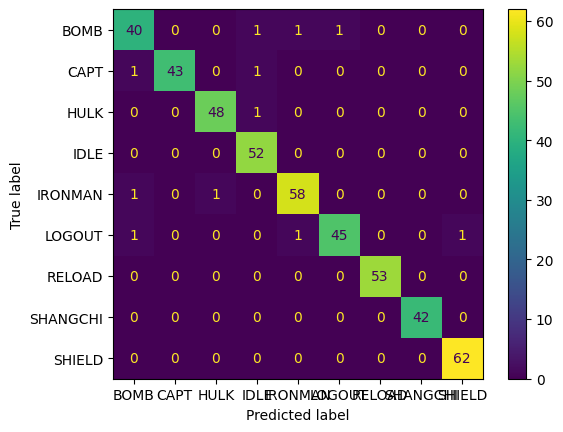

In [121]:
true_labels = []
predicted_labels = []

print(len(test_loader))
inputs, lcheck = next(iter(test_loader))

# Print the shape of the input tensor
print("Input size:", inputs.size())

print(inputs[0])
print(lcheck[0])

for inputs, labels in test_loader:
    print(inputs)
    outputs, _, _, _ = model(inputs)
    _, predicted = torch.max(outputs, 1)
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted.numpy())
    print(predicted_labels)
    print(true_labels)

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

conf_matrix = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(conf_matrix)
cm_display = ConfusionMatrixDisplay(conf_matrix, display_labels = ["BOMB", "CAPT","HULK", "IDLE", "IRONMAN", "LOGOUT","RELOAD", "SHANGCHI", "SHIELD"])
cm_display.plot()
plt.show()

print(test_loader)

In [134]:
ll = [0.3046, 0.7193, 0.6704, 0.3721, 0.2357, 0.0187, 0.8623, 0.1067, 0.4780,
        0.4136, 0.2530, 0.3043, 0.5344, 0.4796, 0.1054, 0.4009, 0.1240, 0.1330,
        0.2945, 0.5003, 0.5310, 0.2218, 0.4113, 0.0317, 0.3493, 0.2564, 0.2690,
        0.4048, 0.6598, 0.6581, 0.3819, 0.4045, 0.0438, 0.6704, 0.6471, 0.4382,
        0.4396, 0.7876, 0.7877, 0.3589, 0.4158, 0.0275, 0.7618, 0.3729, 0.6276,
        0.2239, 0.4045, 0.4384, 0.2986, 0.2973, 0.1271, 0.6328, 0.0450, 0.2286]
tensor2 = torch.Tensor([ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll, ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll])

output, one, two, three = model(tensor2)
print(f"output: {output}")
print(f"one: {one}")
print(f"two: {two}")
print(f"three: {three}")

output: tensor([[9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1

In [122]:
torch.save(model.state_dict(), 'model_weights_biases.pth')

In [133]:
model_weights_path = 'model_weights_biases.pth'
model.load_state_dict(torch.load(model_weights_path))
txt_path = 'model_parameters.txt'
all_weights_and_biases = []
with open(txt_path, 'w') as f:
    for name, param in model.named_parameters():
        # f.write(f"{name}:\n")
        print(name)
        flattened_param = param.flatten().tolist()  # Flatten the parameter tensor
        all_weights_and_biases += flattened_param
        # f.write(f"{flattened_param}\n\n")
        print(len(flattened_param))
    multiplied_list = [int(element * 10000000) for element in all_weights_and_biases]
    f.write(f"{multiplied_list}")
 

print(len(all_weights_and_biases))

print("Model parameters saved to:", txt_path)

fc1.weight
1944
fc1.bias
36
fc2.weight
648
fc2.bias
18
fc3.weight
162
fc3.bias
9
2817
Model parameters saved to: model_parameters.txt
